In [ ]:
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "-U",
                       "datasets", "huggingface_hub", "polars", "pandas",
                       "matplotlib", "seaborn", "tqdm", "pyarrow"])

import os, io, gzip, json, tarfile, zipfile, base64, re, warnings
from pathlib import Path
from collections import Counter, defaultdict
from typing import Any, Dict, Iterator, List, Optional, Union

import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from datasets import load_dataset
from huggingface_hub import HfApi

warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 110
sns.set_style("whitegrid")
sns.set_palette("mako_r")

DATASET_ID = "open-thoughts/TaskTrove"
print("✓ environment ready")

ds_test       = load_dataset(DATASET_ID, split="test",       streaming=True)
ds_validation = load_dataset(DATASET_ID, split="validation", streaming=True)

first = next(iter(ds_test))
print("Keys              :", list(first.keys()))
print("path              :", first["path"])
print("task_binary type  :", type(first["task_binary"]).__name__)
print("task_binary length:", len(first["task_binary"]), "bytes")

In [ ]:
def to_bytes(blob) -> bytes:
    """Coerce whatever `datasets` gives us into raw bytes."""
    if isinstance(blob, (bytes, bytearray)):
        return bytes(blob)
    if isinstance(blob, list):
        return bytes(blob)
    if isinstance(blob, str):
        try:
            return base64.b64decode(blob)
        except Exception:
            return blob.encode("utf-8", errors="replace")
    return bytes(blob)


def parse_task(blob) -> Dict[str, Any]:
    """gunzip + auto-detect tar / zip / json / jsonl / text / binary."""
    raw = to_bytes(blob)
    compressed_size = len(raw)
    data = gzip.decompress(raw) if raw[:2] == b"\x1f\x8b" else raw
    raw_size = len(data)
    bio = io.BytesIO(data)

    try:
        with tarfile.open(fileobj=bio) as tar:
            files: Dict[str, Union[str, bytes]] = {}
            for m in tar.getmembers():
                if not m.isfile():
                    continue
                f = tar.extractfile(m)
                if f is None:
                    continue
                content = f.read()
                try:
                    files[m.name] = content.decode("utf-8")
                except UnicodeDecodeError:
                    files[m.name] = content
            if files:
                return {"format": "tar", "files": files,
                        "raw_size": raw_size, "compressed_size": compressed_size}
    except tarfile.TarError:
        pass

    bio.seek(0)
    try:
        with zipfile.ZipFile(bio) as zf:
            files = {}
            for name in zf.namelist():
                if name.endswith("/"):
                    continue
                with zf.open(name) as zh:
                    content = zh.read()
                    try:
                        files[name] = content.decode("utf-8")
                    except UnicodeDecodeError:
                        files[name] = content
            return {"format": "zip", "files": files,
                    "raw_size": raw_size, "compressed_size": compressed_size}
    except zipfile.BadZipFile:
        pass

    try:
        text = data.decode("utf-8")
        try:
            return {"format": "json", "content": json.loads(text),
                    "raw_size": raw_size, "compressed_size": compressed_size}
        except json.JSONDecodeError:
            try:
                items = [json.loads(l) for l in text.splitlines() if l.strip()]
                return {"format": "jsonl", "content": items,
                        "raw_size": raw_size, "compressed_size": compressed_size}
            except json.JSONDecodeError:
                return {"format": "text", "content": text,
                        "raw_size": raw_size, "compressed_size": compressed_size}
    except UnicodeDecodeError:
        return {"format": "binary", "content": data,
                "raw_size": raw_size, "compressed_size": compressed_size}


raw = to_bytes(first["task_binary"])
print("First 16 bytes (hex):", raw[:16].hex(" "))
task = parse_task(first["task_binary"])
print(f"Format            : {task['format']}")
print(f"Compressed size   : {task['compressed_size']:>10,} bytes")
print(f"Decompressed size : {task['raw_size']:>10,} bytes")
if task["format"] in ("tar", "zip"):
    print(f"Members           : {len(task['files'])}")
    for name in list(task["files"])[:10]:
        body = task["files"][name]
        size = len(body) if isinstance(body, (str, bytes)) else 0
        print(f"  {name:<60} {size:>8} bytes")

In [ ]:
def show_task(task: Dict[str, Any], json_chars: int = 1500, code_chars: int = 600) -> None:
    print("═" * 70)
    print(f"FORMAT: {task['format']}   |   compressed {task['compressed_size']:,} → "
          f"raw {task['raw_size']:,} bytes")
    print("═" * 70)
    if task["format"] not in ("tar", "zip"):
        print(task.get("content", "<binary>"))
        return
    files = task["files"]
    by_ext: Dict[str, List[str]] = defaultdict(list)
    for name in files:
        by_ext[Path(name).suffix.lower() or "<no-ext>"].append(name)
    print("\nFile-type breakdown:")
    for ext, names in sorted(by_ext.items(), key=lambda x: -len(x[1])):
        print(f"  {ext:<10} {len(names):>4} file(s)")

    meta = [n for n in files if n.lower().endswith((".json", ".yaml", ".yml", ".toml"))]
    code = [n for n in files if n.endswith(".py")]
    for name in meta[:3]:
        print(f"\n--- {name} ---")
        body = files[name]
        if isinstance(body, str):
            try:
                pretty = json.dumps(json.loads(body), indent=2)[:json_chars]
            except json.JSONDecodeError:
                pretty = body[:json_chars]
            print(pretty)
            if len(body) > json_chars:
                print(f"… ({len(body)-json_chars:,} more chars)")
    for name in code[:2]:
        print(f"\n--- {name} ---")
        body = files[name]
        if isinstance(body, str):
            print(body[:code_chars])
            if len(body) > code_chars:
                print(f"… ({len(body)-code_chars:,} more chars)")


show_task(task)


def source_of(path: str) -> str:
    return path.rsplit("-", 1)[0] if "-" in path else path


source_counts: Counter = Counter()
compressed_sizes: List[int] = []
for row in tqdm(ds_test, desc="counting paths"):
    source_counts[source_of(row["path"])] += 1
    compressed_sizes.append(len(row["task_binary"]))

print(f"\nUnique source prefixes: {len(source_counts)}")
print("Top 15 sources:")
for src, n in source_counts.most_common(15):
    print(f"  {n:>6}  {src}")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
TOP_N = 15
top = source_counts.most_common(TOP_N)
labels = [s for s, _ in top]
values = [n for _, n in top]
axes[0].barh(range(len(labels)), values, color=sns.color_palette("mako_r", len(labels)))
axes[0].set_yticks(range(len(labels)))
axes[0].set_yticklabels(labels, fontsize=9)
axes[0].invert_yaxis()
axes[0].set_xlabel("number of tasks")
axes[0].set_title(f"Top {TOP_N} sources in test split", fontweight="bold")
for i, v in enumerate(values):
    axes[0].text(v, i, f" {v:,}", va="center", fontsize=8)

axes[1].hist(np.array(compressed_sizes) / 1024, bins=50,
             color=sns.color_palette("mako_r")[2], edgecolor="white")
axes[1].set_xscale("log")
axes[1].set_xlabel("compressed size (KB, log scale)")
axes[1].set_ylabel("# tasks")
axes[1].set_title("Distribution of compressed task sizes", fontweight="bold")
p50 = np.median(compressed_sizes) / 1024
p95 = np.percentile(compressed_sizes, 95) / 1024
axes[1].axvline(p50, color="crimson", linestyle="--", alpha=0.7, label=f"median = {p50:.1f} KB")
axes[1].axvline(p95, color="orange",  linestyle="--", alpha=0.7, label=f"p95    = {p95:.1f} KB")
axes[1].legend()
plt.tight_layout()
plt.show()

In [ ]:
filename_counter: Counter = Counter()
all_json_keys:    Counter = Counter()
samples_for_show: List = []

for i, row in enumerate(tqdm(ds_test, desc="inspecting structure", total=200)):
    if i >= 200:
        break
    p = parse_task(row["task_binary"])
    if p["format"] in ("tar", "zip"):
        for name, body in p["files"].items():
            filename_counter[name] += 1
            if name.endswith(".json") and isinstance(body, str):
                try:
                    obj = json.loads(body)
                    if isinstance(obj, dict):
                        for k in obj.keys():
                            all_json_keys[k] += 1
                except Exception:
                    pass
        if len(samples_for_show) < 2:
            samples_for_show.append((row["path"], p))

print("\nMost common filenames inside task archives:")
for name, n in filename_counter.most_common(15):
    print(f"  {n:>4}  {name}")

print("\nMost common top-level JSON keys (across any *.json):")
for k, n in all_json_keys.most_common(20):
    print(f"  {n:>4}  {k}")

if samples_for_show:
    print(f"\nFull file listing for one sample task ({samples_for_show[0][0]}):")
    for name, body in samples_for_show[0][1]["files"].items():
        sz = len(body) if isinstance(body, (str, bytes)) else 0
        print(f"  {name}  ({sz:,} B)")


VERIFIER_FILE_PATTERNS = ("verifier", "verify", "grader", "judge", "score", "eval")
VERIFIER_JSON_KEYS     = ("verifier", "verifier_config", "judge", "grader",
                          "rubric", "test_patch", "FAIL_TO_PASS", "tests")


def has_verifier(parsed: Dict[str, Any]) -> bool:
    """Detect verifiers via filename, JSON content, or both."""
    if parsed["format"] not in ("tar", "zip"):
        c = parsed.get("content")
        if isinstance(c, dict):
            return any(k in c for k in VERIFIER_JSON_KEYS)
        return False

    files = parsed["files"]

    for name in files:
        low = name.lower()
        if any(pat in low for pat in VERIFIER_FILE_PATTERNS):
            return True

    for name, body in files.items():
        if name.endswith((".json", ".yaml", ".yml")) and isinstance(body, str):
            try:
                obj = json.loads(body)
                if isinstance(obj, dict) and any(k in obj for k in VERIFIER_JSON_KEYS):
                    return True
            except Exception:
                pass
            low = body.lower()
            if "verifier" in low or "test_patch" in low:
                return True

    return False


class TaskTroveExplorer:
    """High-level interface to the open-thoughts/TaskTrove dataset."""

    def __init__(self, split: str = "test", dataset_id: str = DATASET_ID):
        self.dataset_id = dataset_id
        self.split = split
        self._ds = load_dataset(dataset_id, split=split, streaming=True)

    def iter(self, limit: Optional[int] = None,
             source_filter: Optional[str] = None) -> Iterator[Dict[str, Any]]:
        rx = re.compile(source_filter) if source_filter else None
        n = 0
        for row in self._ds:
            if rx and not rx.search(source_of(row["path"])):
                continue
            yield row
            n += 1
            if limit is not None and n >= limit:
                return

    def sample(self, n: int = 5,
               source_filter: Optional[str] = None) -> List[Dict[str, Any]]:
        out = []
        for row in self.iter(limit=n, source_filter=source_filter):
            parsed = parse_task(row["task_binary"])
            parsed["path"] = row["path"]
            parsed["source"] = source_of(row["path"])
            out.append(parsed)
        return out

    def summary(self, limit: int = 1000,
                source_filter: Optional[str] = None) -> pd.DataFrame:
        rows = []
        for row in self.iter(limit=limit, source_filter=source_filter):
            parsed = parse_task(row["task_binary"])
            rows.append({
                "source": source_of(row["path"]),
                "compressed": parsed["compressed_size"],
                "raw": parsed["raw_size"],
                "format": parsed["format"],
                "n_files": len(parsed.get("files", {})),
                "has_verifier": has_verifier(parsed),
            })
        df = pd.DataFrame(rows)
        if df.empty:
            return df
        return (df.groupby("source")
                  .agg(n=("compressed", "count"),
                       mean_compressed_kb=("compressed", lambda s: s.mean()/1024),
                       mean_raw_kb=("raw",                lambda s: s.mean()/1024),
                       mean_n_files=("n_files", "mean"),
                       verifier_rate=("has_verifier", "mean"))
                  .round(2)
                  .sort_values("n", ascending=False))

    @staticmethod
    def has_verifier(parsed: Dict[str, Any]) -> bool:
        return has_verifier(parsed)

    def export(self, output_dir: Union[str, Path], n: int = 10,
               source_filter: Optional[str] = None) -> Path:
        output_dir = Path(output_dir)
        output_dir.mkdir(parents=True, exist_ok=True)
        for parsed in self.sample(n=n, source_filter=source_filter):
            slug = parsed["path"].replace("/", "_")
            tdir = output_dir / slug
            tdir.mkdir(exist_ok=True)
            if parsed["format"] in ("tar", "zip"):
                for name, body in parsed["files"].items():
                    out = tdir / name
                    out.parent.mkdir(parents=True, exist_ok=True)
                    if isinstance(body, str):
                        out.write_text(body, encoding="utf-8")
                    else:
                        out.write_bytes(body)
            else:
                content = parsed.get("content", b"")
                if isinstance(content, (dict, list)):
                    (tdir / "task.json").write_text(json.dumps(content, indent=2))
                elif isinstance(content, str):
                    (tdir / "task.txt").write_text(content)
                else:
                    (tdir / "task.bin").write_bytes(content)
        print(f"✓ exported tasks to {output_dir.resolve()}")
        return output_dir


explorer = TaskTroveExplorer(split="test")

print("\nSample of 3 parsed tasks:")
for s in explorer.sample(n=3):
    print(f"path: {s['path']} | source: {s['source']} | format: {s['format']} | "
          f"files: {len(s.get('files', {}))} | verifier: {has_verifier(s)}")

✓ environment ready


Resolving data files:   0%|          | 0/31 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/31 [00:00<?, ?it/s]

Keys              : ['path', 'task_binary']
path              : methods2test-0000
task_binary type  : bytes
task_binary length: 2452 bytes
First 16 bytes (hex): 1f 8b 08 00 89 83 ab 69 02 ff ed 1c fd 57 1b 37
Format            : tar
Compressed size   :      2,452 bytes
Decompressed size :     30,720 bytes
Members           : 8
  task.toml                                                         310 bytes
  instruction.md                                                   1606 bytes
  metadata.json                                                      75 bytes
  tests/test.sh                                                     484 bytes
  tests/pom.xml                                                    1044 bytes
  tests/TestSolution.java                                           256 bytes
  solution/Solution.java                                            339 bytes
  environment/Dockerfile                                            130 bytes
═══════════════════════════════════════════════

counting paths: 0it [00:00, ?it/s]


Unique source prefixes: 3
Top 15 sources:
   10000  methods2test
      90  llm_verifier_eval_set
       5  r2egym


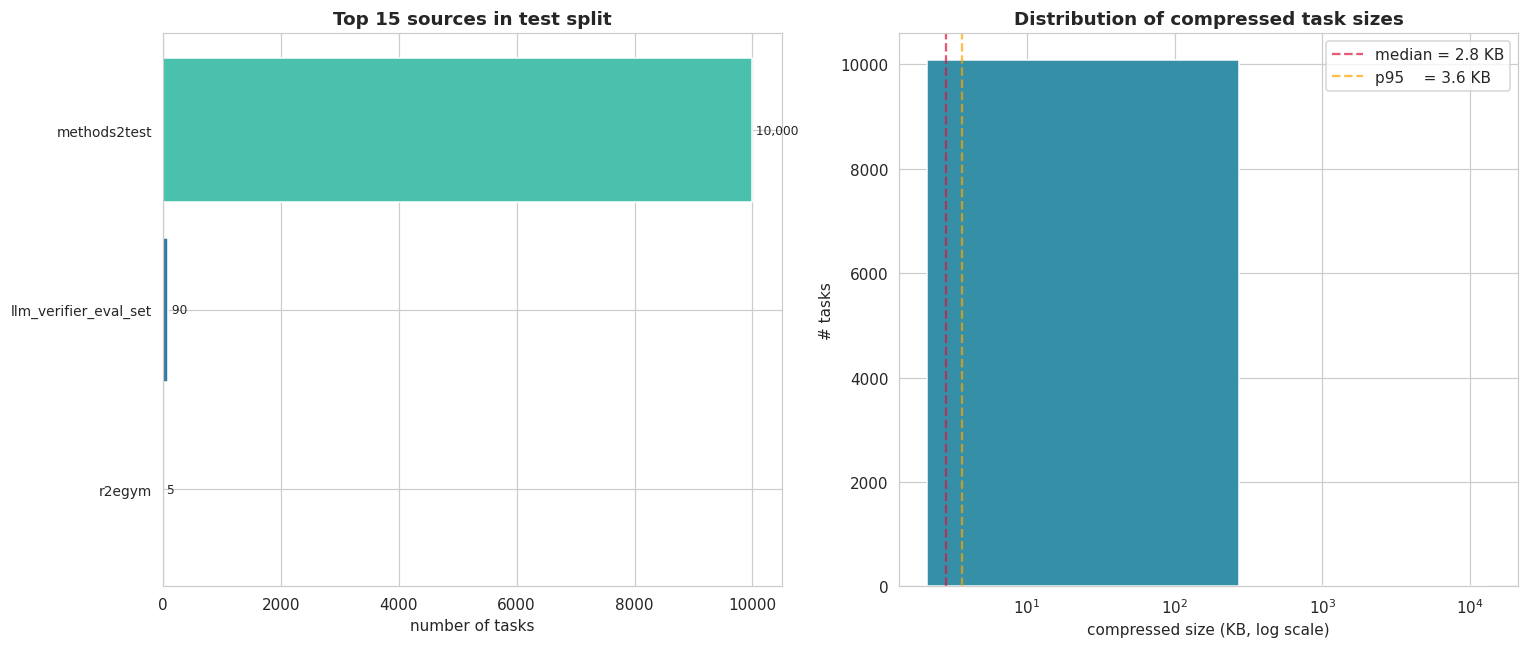

inspecting structure:   0%|          | 0/200 [00:00<?, ?it/s]


Most common filenames inside task archives:
   200  task.toml
   200  instruction.md
   200  metadata.json
   200  tests/test.sh
   200  tests/pom.xml
   200  tests/TestSolution.java
   200  solution/Solution.java
   200  environment/Dockerfile

Most common top-level JSON keys (across any *.json):
   200  source
   200  repo
   200  path
   200  package

Full file listing for one sample task (methods2test-0000):
  task.toml  (310 B)
  instruction.md  (1,606 B)
  metadata.json  (75 B)
  tests/test.sh  (484 B)
  tests/pom.xml  (1,044 B)
  tests/TestSolution.java  (256 B)
  solution/Solution.java  (339 B)
  environment/Dockerfile  (130 B)


Resolving data files:   0%|          | 0/31 [00:00<?, ?it/s]


Sample of 3 parsed tasks:
path: methods2test-0000 | source: methods2test | format: tar | files: 8 | verifier: False
path: methods2test-0000_copy1 | source: methods2test | format: tar | files: 8 | verifier: False
path: methods2test-0001 | source: methods2test | format: tar | files: 8 | verifier: False

Summary across 1 sources (1000 sampled rows):
                 n  mean_compressed_kb  mean_raw_kb  mean_n_files  \
source                                                              
methods2test  1000                2.82        30.56           8.0   

              verifier_rate  
source                       
methods2test            0.0  


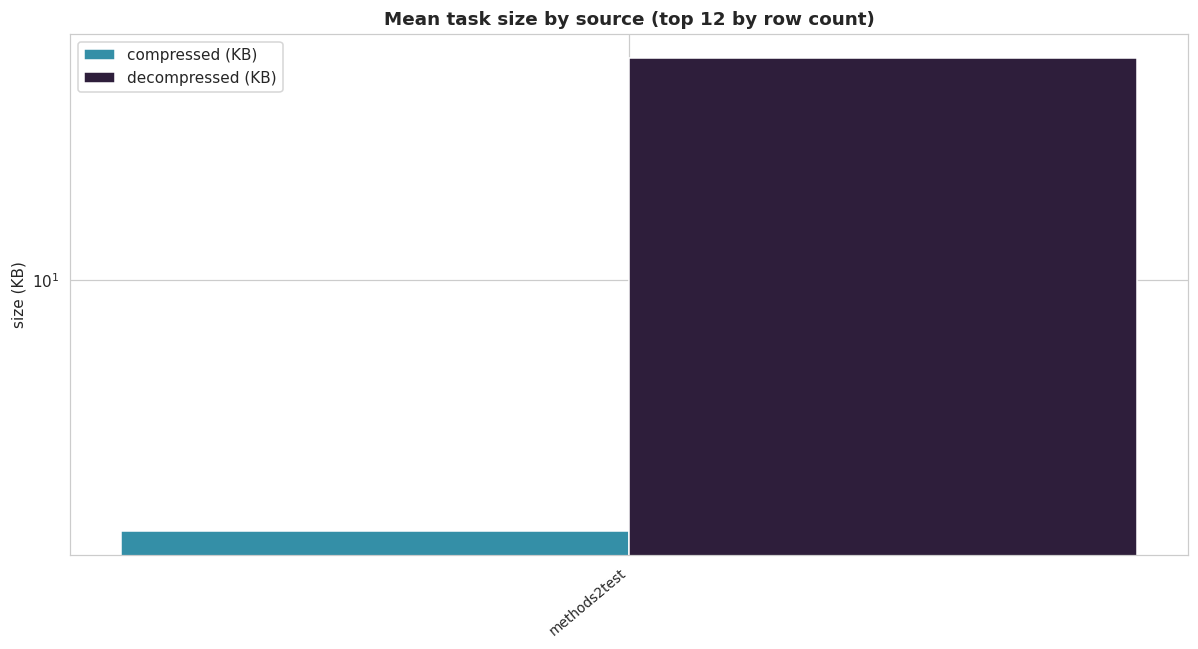

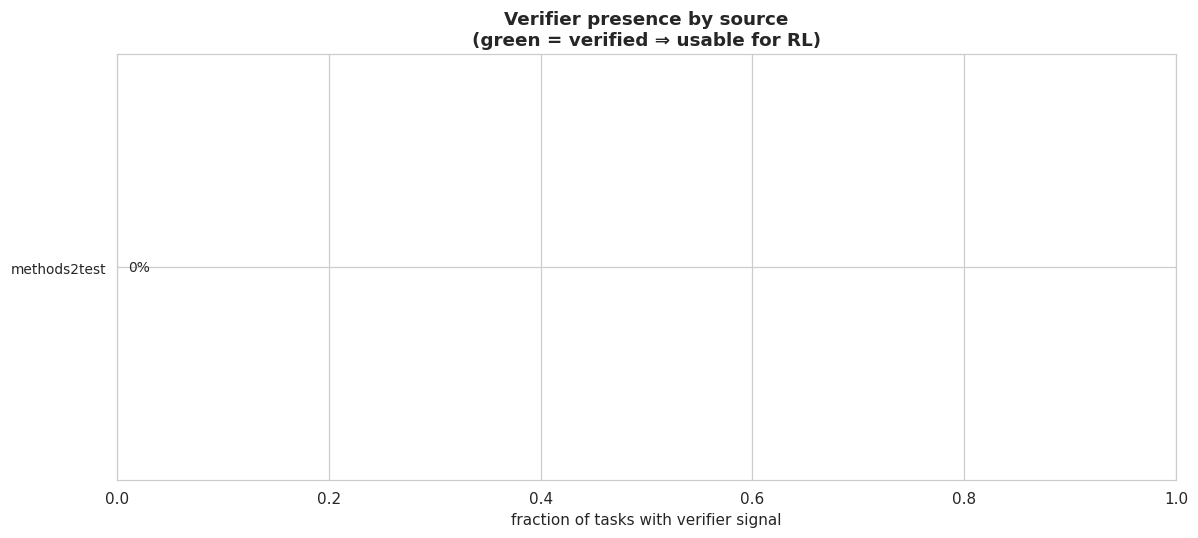

hunting for a verified task: 0it [00:00, ?it/s]

No verified task found in test split — try the validation split.
✓ exported tasks to /content/tasktrove_export
────────────────────────────────────────────────────────────
methods2test-0000
  environment/Dockerfile  (130 B)
  instruction.md  (1,606 B)
  metadata.json  (75 B)
  solution/Solution.java  (339 B)
  task.toml  (310 B)
────────────────────────────────────────────────────────────
methods2test-0000_copy1
  environment/Dockerfile  (130 B)
  instruction.md  (1,606 B)
  metadata.json  (75 B)
  solution/Solution.java  (339 B)
  task.toml  (310 B)
────────────────────────────────────────────────────────────
methods2test-0001
  environment/Dockerfile  (130 B)
  instruction.md  (1,732 B)
  metadata.json  (75 B)
  solution/Solution.java  (296 B)
  task.toml  (310 B)


building slice:   0%|          | 0/500 [00:00<?, ?it/s]


Inspected 500 rows, kept 500 total (0 flagged verified)
shape: (5, 7)
┌─────────────────┬──────────────┬─────────────┬─────────┬───────────────┬────────┬────────────────┐
│ path            ┆ source       ┆ is_verified ┆ n_files ┆ compressed_kb ┆ raw_kb ┆ instruction_pr │
│ ---             ┆ ---          ┆ ---         ┆ ---     ┆ ---           ┆ ---    ┆ eview          │
│ str             ┆ str          ┆ bool        ┆ i64     ┆ f64           ┆ f64    ┆ ---            │
│                 ┆              ┆             ┆         ┆               ┆        ┆ str            │
╞═════════════════╪══════════════╪═════════════╪═════════╪═══════════════╪════════╪════════════════╡
│ methods2test-00 ┆ methods2test ┆ false       ┆ 8       ┆ 2.394531      ┆ 30.0   ┆ ## Task        │
│ 00              ┆              ┆             ┆         ┆               ┆        ┆ Description    │
│                 ┆              ┆             ┆         ┆               ┆        ┆                │
│                 ┆ 

In [2]:
summary = explorer.summary(limit=1000)
print(f"\nSummary across {len(summary)} sources (1000 sampled rows):")
print(summary.head(20))

if not summary.empty:
    top_sources = summary.head(12)
    fig, ax = plt.subplots(figsize=(11, 6))
    x = np.arange(len(top_sources))
    w = 0.4
    ax.bar(x - w/2, top_sources["mean_compressed_kb"], w, label="compressed (KB)",
           color=sns.color_palette("mako_r")[2])
    ax.bar(x + w/2, top_sources["mean_raw_kb"], w, label="decompressed (KB)",
           color=sns.color_palette("mako_r")[5])
    ax.set_xticks(x)
    ax.set_xticklabels(top_sources.index, rotation=40, ha="right", fontsize=9)
    ax.set_ylabel("size (KB)")
    ax.set_yscale("log")
    ax.set_title("Mean task size by source (top 12 by row count)", fontweight="bold")
    ax.legend()
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(11, 5))
    vs = summary.head(15)["verifier_rate"].sort_values()
    colors = sns.color_palette("RdYlGn", as_cmap=True)(vs.values)
    ax.barh(range(len(vs)), vs.values, color=colors)
    ax.set_yticks(range(len(vs)))
    ax.set_yticklabels(vs.index, fontsize=9)
    ax.set_xlabel("fraction of tasks with verifier signal")
    ax.set_xlim(0, 1)
    ax.set_title("Verifier presence by source\n(green = verified ⇒ usable for RL)",
                 fontweight="bold")
    for i, v in enumerate(vs.values):
        ax.text(min(v + 0.01, 0.97), i, f"{v:.0%}", va="center", fontsize=9)
    plt.tight_layout()
    plt.show()


verified_task = None
for row in tqdm(ds_test, desc="hunting for a verified task"):
    parsed = parse_task(row["task_binary"])
    if has_verifier(parsed):
        parsed["path"] = row["path"]
        parsed["source"] = source_of(row["path"])
        verified_task = parsed
        break

if verified_task is None:
    print("No verified task found in test split — try the validation split.")
else:
    print(f"Found verified task: {verified_task['path']}")
    print(f"Source             : {verified_task['source']}")
    if verified_task["format"] in ("tar", "zip"):
        candidates = []
        for n in verified_task["files"]:
            low = n.lower()
            score = sum(p in low for p in VERIFIER_FILE_PATTERNS)
            if n.endswith((".json", ".yaml", ".yml", ".py")):
                score += 1
            candidates.append((score, n))
        candidates.sort(reverse=True)
        for _, name in candidates[:2]:
            body = verified_task["files"][name]
            if isinstance(body, str):
                print(f"\n--- {name} ({len(body):,} chars) ---")
                print(body[:2000])
                if len(body) > 2000:
                    print(f"… ({len(body)-2000:,} more chars)")


EXPORT_DIR = Path("/content/tasktrove_export") if Path("/content").exists() \
             else Path("./tasktrove_export")
EXPORT_DIR.mkdir(exist_ok=True)
explorer.export(EXPORT_DIR, n=5)

for task_dir in sorted(EXPORT_DIR.iterdir())[:3]:
    print("─" * 60)
    print(task_dir.name)
    for sub in sorted(task_dir.rglob("*"))[:8]:
        if sub.is_file():
            print(f"  {sub.relative_to(task_dir)}  ({sub.stat().st_size:,} B)")


rows: List[Dict[str, Any]] = []
MAX_TASKS = 500
n_seen = 0

for row in tqdm(ds_test, desc="building slice", total=MAX_TASKS):
    parsed = parse_task(row["task_binary"])
    n_seen += 1
    src = source_of(row["path"])
    is_verified = has_verifier(parsed) or "verifier" in src.lower()

    files = parsed.get("files", {})
    instruction = ""
    for name in files:
        if name.endswith((".json", ".md", ".txt")) and isinstance(files[name], str):
            if len(files[name]) > len(instruction):
                instruction = files[name]

    rows.append({
        "path": row["path"],
        "source": src,
        "is_verified": bool(is_verified),
        "n_files": len(files),
        "compressed_kb": parsed["compressed_size"] / 1024,
        "raw_kb": parsed["raw_size"] / 1024,
        "instruction_preview": instruction[:300],
    })
    if len(rows) >= MAX_TASKS:
        break

df = pl.DataFrame(rows)
print(f"\nInspected {n_seen} rows, kept {len(df)} total "
      f"({df['is_verified'].sum() if len(df) else 0} flagged verified)")
if len(df):
    print(df.head(5))

if len(df) == 0:
    print("Empty slice — nothing to aggregate or save.")
else:
    grouped = (df.group_by("source")
                 .agg([pl.len().alias("n"),
                       pl.col("is_verified").sum().alias("n_verified"),
                       pl.col("raw_kb").mean().round(1).alias("mean_raw_kb"),
                       pl.col("n_files").mean().round(1).alias("mean_n_files")])
                 .sort("n", descending=True))
    print("\nSlice composition by source:")
    print(grouped)

    out_path = (Path("/content") if Path("/content").exists() else Path(".")) \
               / "tasktrove_slice.parquet"
    df.write_parquet(out_path)
    print(f"\n✓ wrote {len(df)} rows to {out_path} "
          f"({out_path.stat().st_size/1024:.1f} KB)")


api = HfApi()
files = api.list_repo_files(repo_id=DATASET_ID, repo_type="dataset")
subdirs = sorted({f.split("/", 1)[0] for f in files
                  if "/" in f and "__" in f.split("/", 1)[0]})
print(f"\nFound {len(subdirs)} source-dataset subdirectories. First 25:")
for s in subdirs[:25]:
    print(" ", s)